In [1]:
import os
os.environ.pop("TF_USE_LEGACY_KERAS", None)


import librosa
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio
import numpy as np
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
from sklearn.metrics import confusion_matrix
import IPython.display as ipd
import sys

data = pd.read_csv('../../data/featureEmodb.csv')

2025-11-04 14:40:19.410971: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-04 14:40:19.479918: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-04 14:40:21.172404: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [1]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [2]:
data

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,emo,speaker
0,-290.069550,120.892410,-44.022133,59.493820,-25.234184,24.166288,-20.102554,-3.104467,-3.912210,-8.433292,...,56.398769,0.009679,0.012519,-0.031646,0.024728,0.007912,0.001966,0,6,3
1,-274.512543,137.867325,-33.016861,49.305836,-7.529972,15.471715,-6.811347,-7.069037,-8.804790,-1.528063,...,53.806400,-0.001984,0.006133,-0.084608,0.109369,-0.025859,-0.003522,0,3,3
2,-225.866470,94.075874,-72.961555,41.311485,-27.577299,12.030844,-14.943604,-8.053857,-11.431667,-10.043902,...,54.852081,0.001015,-0.006297,-0.033966,-0.076824,0.011315,-0.001692,0,1,3
3,-273.849060,98.794968,-36.564865,36.316208,-22.404598,18.368185,-12.455775,-1.077722,-12.487121,-17.107168,...,58.313221,0.039030,-0.017753,-0.081100,-0.049775,0.015536,-0.007109,0,6,3
4,-252.887863,149.398911,-24.717367,45.297226,-0.930259,5.930630,0.473345,-0.681704,-12.864426,-9.714954,...,51.336941,0.008184,-0.018455,-0.020061,-0.058433,0.009487,0.034003,0,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,-255.980286,105.676674,-42.180950,75.896423,-23.686800,10.384299,-17.101816,-5.522916,-3.057154,-10.192598,...,56.598065,0.013773,-0.044897,0.036112,-0.103853,0.014030,0.004264,1,2,16
531,-246.298492,91.399818,-25.200518,57.381245,-6.517654,19.359470,-4.424452,-3.416811,2.381373,-6.032308,...,56.940429,0.022640,0.051658,0.111283,0.034628,0.032623,-0.023948,1,7,16
532,-287.566315,88.560669,-21.810999,60.376926,-0.650359,19.902147,-0.450192,2.266046,3.220632,-6.157897,...,56.867307,0.064417,0.045792,-0.014448,0.036817,-0.002728,-0.039342,1,7,16
533,-329.608124,67.631531,-87.368507,64.361099,-49.395180,-1.466112,-20.686680,-10.990952,-6.811410,-28.455215,...,53.589258,0.004312,0.004346,-0.046711,-0.008183,-0.011669,0.014701,1,1,16


In [3]:
df = data
df.shape

(535, 196)

In [4]:
df

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,emo,speaker
0,-290.069550,120.892410,-44.022133,59.493820,-25.234184,24.166288,-20.102554,-3.104467,-3.912210,-8.433292,...,56.398769,0.009679,0.012519,-0.031646,0.024728,0.007912,0.001966,0,6,3
1,-274.512543,137.867325,-33.016861,49.305836,-7.529972,15.471715,-6.811347,-7.069037,-8.804790,-1.528063,...,53.806400,-0.001984,0.006133,-0.084608,0.109369,-0.025859,-0.003522,0,3,3
2,-225.866470,94.075874,-72.961555,41.311485,-27.577299,12.030844,-14.943604,-8.053857,-11.431667,-10.043902,...,54.852081,0.001015,-0.006297,-0.033966,-0.076824,0.011315,-0.001692,0,1,3
3,-273.849060,98.794968,-36.564865,36.316208,-22.404598,18.368185,-12.455775,-1.077722,-12.487121,-17.107168,...,58.313221,0.039030,-0.017753,-0.081100,-0.049775,0.015536,-0.007109,0,6,3
4,-252.887863,149.398911,-24.717367,45.297226,-0.930259,5.930630,0.473345,-0.681704,-12.864426,-9.714954,...,51.336941,0.008184,-0.018455,-0.020061,-0.058433,0.009487,0.034003,0,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,-255.980286,105.676674,-42.180950,75.896423,-23.686800,10.384299,-17.101816,-5.522916,-3.057154,-10.192598,...,56.598065,0.013773,-0.044897,0.036112,-0.103853,0.014030,0.004264,1,2,16
531,-246.298492,91.399818,-25.200518,57.381245,-6.517654,19.359470,-4.424452,-3.416811,2.381373,-6.032308,...,56.940429,0.022640,0.051658,0.111283,0.034628,0.032623,-0.023948,1,7,16
532,-287.566315,88.560669,-21.810999,60.376926,-0.650359,19.902147,-0.450192,2.266046,3.220632,-6.157897,...,56.867307,0.064417,0.045792,-0.014448,0.036817,-0.002728,-0.039342,1,7,16
533,-329.608124,67.631531,-87.368507,64.361099,-49.395180,-1.466112,-20.686680,-10.990952,-6.811410,-28.455215,...,53.589258,0.004312,0.004346,-0.046711,-0.008183,-0.011669,0.014701,1,1,16


In [5]:
X_speaker = df.iloc[:, -1].copy()
X = df.iloc[:, :-3].copy()
y = df.iloc[:,-2].copy()

In [6]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-290.069550,120.892410,-44.022133,59.493820,-25.234184,24.166288,-20.102554,-3.104467,-3.912210,-8.433292,...,14.751010,17.490223,16.878034,56.398769,0.009679,0.012519,-0.031646,0.024728,0.007912,0.001966
1,-274.512543,137.867325,-33.016861,49.305836,-7.529972,15.471715,-6.811347,-7.069037,-8.804790,-1.528063,...,14.512919,17.550766,19.076122,53.806400,-0.001984,0.006133,-0.084608,0.109369,-0.025859,-0.003522
2,-225.866470,94.075874,-72.961555,41.311485,-27.577299,12.030844,-14.943604,-8.053857,-11.431667,-10.043902,...,16.131910,18.237524,19.299087,54.852081,0.001015,-0.006297,-0.033966,-0.076824,0.011315,-0.001692
3,-273.849060,98.794968,-36.564865,36.316208,-22.404598,18.368185,-12.455775,-1.077722,-12.487121,-17.107168,...,15.816742,17.617843,17.377833,58.313221,0.039030,-0.017753,-0.081100,-0.049775,0.015536,-0.007109
4,-252.887863,149.398911,-24.717367,45.297226,-0.930259,5.930630,0.473345,-0.681704,-12.864426,-9.714954,...,14.601713,14.795569,19.625183,51.336941,0.008184,-0.018455,-0.020061,-0.058433,0.009487,0.034003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,-255.980286,105.676674,-42.180950,75.896423,-23.686800,10.384299,-17.101816,-5.522916,-3.057154,-10.192598,...,16.838569,17.835524,19.693569,56.598065,0.013773,-0.044897,0.036112,-0.103853,0.014030,0.004264
531,-246.298492,91.399818,-25.200518,57.381245,-6.517654,19.359470,-4.424452,-3.416811,2.381373,-6.032308,...,15.286078,17.031323,18.757498,56.940429,0.022640,0.051658,0.111283,0.034628,0.032623,-0.023948
532,-287.566315,88.560669,-21.810999,60.376926,-0.650359,19.902147,-0.450192,2.266046,3.220632,-6.157897,...,14.402789,15.672307,17.590725,56.867307,0.064417,0.045792,-0.014448,0.036817,-0.002728,-0.039342
533,-329.608124,67.631531,-87.368507,64.361099,-49.395180,-1.466112,-20.686680,-10.990952,-6.811410,-28.455215,...,19.920409,19.619588,21.609127,53.589258,0.004312,0.004346,-0.046711,-0.008183,-0.011669,0.014701


In [7]:
y

0      6
1      3
2      1
3      6
4      3
      ..
530    2
531    7
532    7
533    1
534    1
Name: emo, Length: 535, dtype: int64

In [8]:
X_speaker

0       3
1       3
2       3
3       3
4       3
       ..
530    16
531    16
532    16
533    16
534    16
Name: speaker, Length: 535, dtype: int64

In [9]:
X.shape, y.shape

((535, 193), (535,))

In [10]:
from sklearn.utils import shuffle

X, y, X_speaker = shuffle(X, y, X_speaker, random_state=42)

In [11]:
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
y1 = to_categorical(lb.fit_transform(y))

In [12]:
y1

array([[0., 0., 1., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(535, 7))

In [13]:
X.shape, y1.shape

((535, 193), (535, 7))

In [14]:
X2_speaker = X_speaker.copy().to_numpy()
X2=X.copy().to_numpy()
y2=y.copy().to_numpy()

In [15]:
X2.shape, X2_speaker.shape, y2.shape

((535, 193), (535,), (535,))

In [16]:
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.pyplot import specgram
import keras

from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding, Activation
from keras.layers import LSTM

from keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout#, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix
from keras.layers import BatchNormalization

def model1(input_shape1):
    model = Sequential()

    model.add(Conv1D(256, 5,padding='same',
                     input_shape=(input_shape1,1)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))


    model.add(Conv1D(256, 5,padding='same'))
    model.add(Activation('relu'))
    model.add(Dropout(0.1))

    model.add(BatchNormalization())

    model.add(MaxPooling1D(pool_size=(8)))
    model.add(Conv1D(256, 5,padding='same',))

    model.add(Activation('relu'))

    model.add(Conv1D(128, 5,padding='same',))
    model.add(Activation('relu'))
    model.add(Conv1D(128, 5,padding='same',))
    model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(Dropout(0.2))

    model.add(Flatten())
    model.add(Dropout(0.2))
    model.add(Dense(7))
    model.add(BatchNormalization())
    model.add(Activation('softmax'))

    return model

In [17]:
import random, numpy as np
from keras import optimizers
kfold=5
def create_index(kfold, size):
    a = []
    for i in range(size):
        a.append(i)
    random.shuffle(a)
    arr = np.array(a)
    return arr.reshape(kfold, size//kfold)

In [18]:
X3=pd.DataFrame(X2)
X3

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-239.764008,139.099991,-36.230679,64.189774,-15.741068,25.634315,-4.790334,-11.361882,-4.120832,-5.749265,...,14.843166,17.267064,20.333906,52.065033,0.024090,0.007341,0.069747,-0.166069,0.011784,0.016121
1,-260.317963,83.698997,-62.219009,62.837143,-29.033827,-5.925933,-19.271563,-22.503176,-11.056346,-14.001642,...,17.166468,18.111217,22.519248,54.400206,-0.004591,0.047589,-0.013484,0.051093,0.001319,0.016818
2,-258.790070,111.870972,-39.346752,41.019382,-7.644496,12.690877,-9.099957,-7.537449,-21.245274,-4.533050,...,16.004872,17.305083,18.331014,55.222186,-0.014079,-0.010854,0.063290,-0.047139,0.007506,-0.007546
3,-248.415848,140.136810,-54.752460,59.543102,-15.653415,13.293295,-11.262449,-3.968599,-12.746889,-5.119174,...,15.127516,17.180208,18.952523,55.315247,0.024211,0.022074,-0.025763,-0.078729,-0.007502,-0.008905
4,-271.101715,114.182411,-38.098175,28.942293,-24.289883,4.521724,-15.069010,-4.291117,-13.700146,-10.009334,...,18.606591,19.001541,18.857394,57.109288,-0.009274,0.027404,-0.000096,-0.020396,0.009333,-0.022284
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,-227.954727,85.081978,-58.060806,36.880703,-40.687836,12.664502,-30.147270,-10.475245,-2.788741,-18.911095,...,17.908426,19.134608,18.232150,58.157041,0.024658,-0.009180,-0.002439,0.034757,0.021257,-0.008066
531,-281.011719,81.203072,-46.238575,46.518276,-30.387165,4.483186,-15.096430,-2.682035,-10.517467,-20.056936,...,18.526438,19.252223,18.605096,57.006848,0.008616,0.009848,-0.021393,-0.002289,-0.009699,0.001744
532,-210.938858,138.555298,-38.752594,46.934879,-27.053715,-1.506808,3.063251,-5.027531,-23.228069,-7.718493,...,18.211423,17.517405,21.065693,56.056814,-0.017440,0.011268,-0.033607,-0.010188,-0.000729,-0.027539
533,-218.649277,122.726830,-28.866823,65.878014,-7.769287,35.246620,-3.790648,6.997354,-5.520399,-8.897484,...,15.274676,16.397692,18.600169,57.831954,0.032818,0.117523,0.122300,-0.055600,-0.050631,0.028001


In [19]:
X3_speaker = pd.DataFrame(X2_speaker)
X3_speaker

,0
0,9
1,9
2,10
3,12
4,8
...,...
530,8
531,8
532,12
533,15


In [20]:
speakers = X_speaker.unique()
speakers

array([ 9, 10, 12,  8, 14,  3, 16, 13, 11, 15])

In [21]:
X3_col = X3_speaker.rename(columns={0: 'speaker'})
X3_col

,speaker
0,9
1,9
2,10
3,12
4,8
...,...
530,8
531,8
532,12
533,15


In [22]:
X_combined = pd.concat([X3, X3_col], axis=1)
X_combined

,0,1,2,3,4,5,6,7,8,9,...,184,185,186,187,188,189,190,191,192,speaker
0,-239.764008,139.099991,-36.230679,64.189774,-15.741068,25.634315,-4.790334,-11.361882,-4.120832,-5.749265,...,17.267064,20.333906,52.065033,0.024090,0.007341,0.069747,-0.166069,0.011784,0.016121,9
1,-260.317963,83.698997,-62.219009,62.837143,-29.033827,-5.925933,-19.271563,-22.503176,-11.056346,-14.001642,...,18.111217,22.519248,54.400206,-0.004591,0.047589,-0.013484,0.051093,0.001319,0.016818,9
2,-258.790070,111.870972,-39.346752,41.019382,-7.644496,12.690877,-9.099957,-7.537449,-21.245274,-4.533050,...,17.305083,18.331014,55.222186,-0.014079,-0.010854,0.063290,-0.047139,0.007506,-0.007546,10
3,-248.415848,140.136810,-54.752460,59.543102,-15.653415,13.293295,-11.262449,-3.968599,-12.746889,-5.119174,...,17.180208,18.952523,55.315247,0.024211,0.022074,-0.025763,-0.078729,-0.007502,-0.008905,12
4,-271.101715,114.182411,-38.098175,28.942293,-24.289883,4.521724,-15.069010,-4.291117,-13.700146,-10.009334,...,19.001541,18.857394,57.109288,-0.009274,0.027404,-0.000096,-0.020396,0.009333,-0.022284,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,-227.954727,85.081978,-58.060806,36.880703,-40.687836,12.664502,-30.147270,-10.475245,-2.788741,-18.911095,...,19.134608,18.232150,58.157041,0.024658,-0.009180,-0.002439,0.034757,0.021257,-0.008066,8
531,-281.011719,81.203072,-46.238575,46.518276,-30.387165,4.483186,-15.096430,-2.682035,-10.517467,-20.056936,...,19.252223,18.605096,57.006848,0.008616,0.009848,-0.021393,-0.002289,-0.009699,0.001744,8
532,-210.938858,138.555298,-38.752594,46.934879,-27.053715,-1.506808,3.063251,-5.027531,-23.228069,-7.718493,...,17.517405,21.065693,56.056814,-0.017440,0.011268,-0.033607,-0.010188,-0.000729,-0.027539,12
533,-218.649277,122.726830,-28.866823,65.878014,-7.769287,35.246620,-3.790648,6.997354,-5.520399,-8.897484,...,16.397692,18.600169,57.831954,0.032818,0.117523,0.122300,-0.055600,-0.050631,0.028001,15


In [23]:
# Get top 5 speakers with the most data

speaker_counts = X_combined['speaker'].value_counts()
selected_speakers = speaker_counts.head(5).index.to_numpy()

print("Selected speakers:", selected_speakers)

Selected speakers: [16 14 13  8 15]


In [24]:
from skfeature.function.similarity_based import fisher_score
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

hist=[]
scores=[]
totalsize=535
num_fea=125
a=create_index(kfold,totalsize)

for i in range (kfold):
    model_name = 'Model_'+str(i)
    savedir='emodb_speaker_both'
    model_path = os.path.join(savedir, (model_name+'.h5'))

    # Choose one test speaker from selected_speakers
    test_speaker = selected_speakers[i]

    # Use only speakers not in selected_speakers as training
    train_speakers = np.setdiff1d(speakers, [test_speaker])

    print(f"\n===== Fold {i} =====")
    print("Test speaker:", test_speaker)
    print("Train speakers:", train_speakers)

    # Get the indices for test and train
    train_indices = X_combined[X_combined['speaker'].isin(train_speakers)].index
    test_indices = X_combined[X_combined['speaker'] == test_speaker].index


    # Sanity check for overlaps
    overlap_indices = np.intersect1d(train_indices, test_indices)
    if len(overlap_indices) > 0:
        print(f"Overlap found in fold {i}! Overlapping indices: {overlap_indices}")
    else:
        print(f"No overlap in fold {i}.")

    
    # Prepare training and testing sets
    X_train = X_combined.drop(columns=['speaker']).iloc[train_indices, :]
    y_train = y1[train_indices, :]
    y_train_fs = y.iloc[train_indices].to_numpy().ravel()

    X_test = X_combined.drop(columns=['speaker']).iloc[test_indices, :]
    y_test = y1[test_indices, :]


    # Scale separately
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Fisher score feature selection (on training data only)
    score = fisher_score.fisher_score(X_train_scaled, y_train_fs)
    sorted_indices = np.argsort(score)[::-1]
    fs_indices = sorted_indices[:num_fea]

    print(f"Top {num_fea} features: {fs_indices[:10]} ...")
    
    # Select top features
    X_train_fs = X_train_scaled[:, fs_indices]
    X_test_fs = X_test_scaled[:, fs_indices]

    # CNN input shape adjustment
    x_traincnn = np.expand_dims(X_train_fs, axis=2)
    x_testcnn = np.expand_dims(X_test_fs, axis=2)

    m1= model1(x_traincnn.shape[1])
    opt = tf.keras.optimizers.RMSprop(learning_rate=0.00005, decay=1e-6)
    m1.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_accuracy', patience=700, restore_best_weights=True)

    # Train
    history = m1.fit(
        x_traincnn, y_train,
        batch_size=32, epochs=700,
        validation_data=(x_testcnn, y_test),
        callbacks=[early_stopping],
        verbose=1
    )
    hist.append(history)

    # Evaluate
    score_eval = m1.evaluate(x_testcnn, y_test, verbose=0)
    scores.append(score_eval)
    print(f"Fold {i} Test Accuracy: {score_eval[1]:.4f}")

    # Save data for reproducibility
    np.save(os.path.join(savedir, f"X_train_fold{i}.npy"), x_traincnn)
    np.save(os.path.join(savedir, f"y_train_fold{i}.npy"), y_train)

    np.save(os.path.join(savedir, f"X_test_fold{i}.npy"), x_testcnn)
    np.save(os.path.join(savedir, f"y_test_fold{i}.npy"), y_test)

    # Save model
    model_name = f"Model_{i}.h5"
    model_path = os.path.join(savedir, model_name)
    model_json = m1.to_json()
    with open(os.path.join(savedir, f"Model_{i}.json"), "w") as json_file:
        json_file.write(model_json)
    m1.save(model_path)


print("\n===== Cross-validation results =====")
for i, sc in enumerate(scores):
    print(f"Fold {i}: Loss={sc[0]:.4f}, Accuracy={sc[1]:.4f}")
print(f"\nAverage accuracy: {np.mean([s[1] for s in scores]):.4f}")


===== Fold 0 =====
Test speaker: 16
Train speakers: [ 3  8  9 10 11 12 13 14 15]
No overlap in fold 0.
Top 125 features: [ 75   1   0   9   3   5   2 104  25  11] ...


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1762249229.317834    6679 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.2478 - loss: 1.9707 - val_accuracy: 0.1972 - val_loss: 1.9421
Epoch 2/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.4181 - loss: 1.5667 - val_accuracy: 0.1831 - val_loss: 1.9452
Epoch 3/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.4655 - loss: 1.4282 - val_accuracy: 0.1831 - val_loss: 1.9467
Epoch 4/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.5431 - loss: 1.3202 - val_accuracy: 0.1972 - val_loss: 1.9447
Epoch 5/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.5970 - loss: 1.2050 - val_accuracy: 0.2113 - val_loss: 1.9422
Epoch 6/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.6466 - loss: 1.1422 - val_accuracy: 0.1690 - val_loss: 1.9417
Epoch 7/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.6918 - loss: 1.0887 - val_accuracy: 0.1549 - val_loss: 1.9394
Epoch 8/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.7047 - loss: 1.0551 - val_accuracy: 0.1972 - val_l

...

Epoch 1/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.2390 - loss: 1.9271 - val_accuracy: 0.1897 - val_loss: 1.9422
Epoch 2/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4465 - loss: 1.5177 - val_accuracy: 0.1552 - val_loss: 1.9588
Epoch 3/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4717 - loss: 1.3679 - val_accuracy: 0.0517 - val_loss: 1.9782
Epoch 4/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5786 - loss: 1.2622 - val_accuracy: 0.0000e+00 - val_loss: 1.9975
Epoch 5/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6415 - loss: 1.1714 - val_accuracy: 0.0000e+00 - val_loss: 2.0250
Epoch 6/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6457 - loss: 1.1439 - val_accuracy: 0.0000e+00 - val_loss: 2.0417
Epoch 7/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7107 - loss: 1.0430 - val_accuracy: 0.0000e+00 - val_loss: 2.0562
Epoch 8/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7379 - loss: 1.0221 - 

Fold 3 Test Accuracy: 0.7069

===== Fold 4 =====
Test speaker: 15
Train speakers: [ 3  8  9 10 11 12 13 14 16]
No overlap in fold 4.
Top 125 features: [68  4  0 12  1  3  2 81 28  8] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.2401 - loss: 1.9959 - val_accuracy: 0.2321 - val_loss: 1.9341
Epoch 2/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4217 - loss: 1.5479 - val_accuracy: 0.2321 - val_loss: 1.9335
Epoch 3/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5094 - loss: 1.3740 - val_accuracy: 0.2857 - val_loss: 1.9516
Epoch 4/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6221 - loss: 1.2280 - val_accuracy: 0.1429 - val_loss: 1.9704
Epoch 5/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6326 - loss: 1.1779 - val_accuracy: 0.1071 - val_loss: 1.9939
Epoch 6/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6764 - loss: 1.1242 - val_accuracy: 0.1071 - val_loss: 2.0150
Epoch 7/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7077 - loss: 1.0309 - val_accuracy: 0.1071 - val_loss: 2.0278
Epoch 8/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7599 - loss: 0.9736 - val_accuracy: 0.0893 - val_l

Fold 4 Test Accuracy: 0.6786

===== Cross-validation results =====
Fold 0: Loss=1.5170, Accuracy=0.4789
Fold 1: Loss=1.1289, Accuracy=0.7391
Fold 2: Loss=1.1464, Accuracy=0.7869
Fold 3: Loss=1.2593, Accuracy=0.7069
Fold 4: Loss=1.2901, Accuracy=0.6786

Average accuracy: 0.6781


In [1]:
import numpy as np
import keras
from keras.models import model_from_json
from sklearn.metrics import confusion_matrix, classification_report

savedir = 'emodb_speaker_both'
num_folds = 5
opt = keras.optimizers.RMSprop(learning_rate=0.00001, decay=1e-6)

accuracies = []
conf_matrices = []

listik = ['angry', 'bored', 'neutral', 'disgust', 'fear', 'happy', 'sad']

fold_reports = []
fold_macro_f1 = []

for i in range(num_folds):
    model_name = f"Model_{i}"
    with open(f"{savedir}/{model_name}.json", "r") as json_file:
        loaded_model = model_from_json(json_file.read())
    loaded_model.load_weights(f"{savedir}/{model_name}.h5")
    loaded_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    X_test = np.load(f"{savedir}/X_test_fold{i}.npy")
    y_test = np.load(f"{savedir}/y_test_fold{i}.npy")

    score = loaded_model.evaluate(X_test, y_test, verbose=0)
    acc = score[1] * 100
    accuracies.append(acc)

    y_pred = loaded_model.predict(X_test, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    conf_matrices.append(cm)

    report_dict = classification_report(y_true_labels, y_pred_labels,
                                        target_names=listik, digits=4, output_dict=True)
    fold_reports.append(report_dict)
    fold_macro_f1.append(report_dict['macro avg']['f1-score'])

    print(f"\n{'='*60}")
    print(f"Fold {i}: Accuracy = {acc:.2f}%")
    print(f"{'='*60}")
    print(classification_report(y_true_labels, y_pred_labels,
                                target_names=listik, digits=4))

# array: (num_folds, num_classes, num_classes)
conf_matrices = np.array(conf_matrices)

mean_acc = np.mean(accuracies)
print("\nMean Accuracy: %.2f%%" % mean_acc)
print("SD Accuracy: %.2f" % np.std(accuracies))
n = num_folds
ci95 = 1.96 * (np.std(accuracies) / np.sqrt(n))
ci_low = mean_acc - ci95
ci_high = mean_acc + ci95
print(f"95% CI: [{ci_low:.2f}%, {ci_high:.2f}%]")


# Macro-F1 summary
macro_f1_arr = np.array(fold_macro_f1)
mean_macro_f1 = np.mean(macro_f1_arr)
std_macro_f1 = np.std(macro_f1_arr)
ci95_f1 = 1.96 * (std_macro_f1 / np.sqrt(num_folds))
print(f"\nMacro-F1: {mean_macro_f1:.4f} ± {std_macro_f1:.4f}  "
      f"\n95% CI: [{mean_macro_f1 - ci95_f1:.4f}, {mean_macro_f1 + ci95_f1:.4f}]")

# Per-class precision / recall / F1 (mean ± SD across folds)
print(f"\n{' Per-Class Metrics (mean ± SD across folds)':=^93}\n")
print(f"{'Class':<12} {'Precision':>20} {'Recall':>20} {'F1-Score':>20} {'Support':>17}")
print("-" * 93)
for cls in listik:
    p = np.array([r[cls]['precision'] for r in fold_reports])
    r = np.array([r[cls]['recall'] for r in fold_reports])
    f = np.array([r[cls]['f1-score'] for r in fold_reports])
    s = np.array([r[cls]['support'] for r in fold_reports])
    print(f"{cls:<12}        "
          f"{np.mean(p):>6.4f} ± {np.std(p):<6.4f}       "
          f"{np.mean(r):>6.4f} ± {np.std(r):<6.4f}       "
          f"{np.mean(f):>6.4f} ± {np.std(f):<6.4f}     "
          f"{np.mean(s):>8.1f}")
print("-" * 93)

2026-03-01 16:06:37.236583: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-01 16:06:37.236821: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-01 16:06:37.265927: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-01 16:06:37.918066: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or


Fold 0: Accuracy = 47.89%
              precision    recall  f1-score   support

       angry     0.5385    1.0000    0.7000        14
       bored     1.0000    0.3571    0.5263        14
     neutral     0.5000    0.2000    0.2857         5
     disgust     0.4737    0.8182    0.6000        11
        fear     0.1667    0.1429    0.1538         7
       happy     0.3077    0.3636    0.3333        11
         sad     0.0000    0.0000    0.0000         9

    accuracy                         0.4789        71
   macro avg     0.4266    0.4117    0.3713        71
weighted avg     0.4761    0.4789    0.4217        71


Fold 1: Accuracy = 73.91%
              precision    recall  f1-score   support

       angry     0.7143    0.9375    0.8108        16
       bored     0.6364    0.8750    0.7368         8
     neutral     0.6000    0.4286    0.5000         7
     disgust     0.6250    0.6250    0.6250         8
        fear     0.8000    0.6667    0.7273        12
       happy     1.0000 

/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi


Fold 3: Accuracy = 70.69%
              precision    recall  f1-score   support

       angry     0.9091    0.8333    0.8696        12
       bored     1.0000    0.8000    0.8889        10
     neutral     0.8000    0.4000    0.5333        10
     disgust     0.0000    0.0000    0.0000         0
        fear     0.3333    0.5000    0.4000         6
       happy     0.5385    0.6364    0.5833        11
         sad     1.0000    1.0000    1.0000         9

    accuracy                         0.7069        58
   macro avg     0.6544    0.5957    0.6107        58
weighted avg     0.7902    0.7069    0.7323        58


Fold 4: Accuracy = 67.86%
              precision    recall  f1-score   support

       angry     0.6500    1.0000    0.7879        13
       bored     1.0000    0.2222    0.3636         9
     neutral     0.9091    0.9091    0.9091        11
     disgust     1.0000    0.6000    0.7500         5
        fear     0.6667    0.5000    0.5714         8
       happy     1.0000 

/tmp/ipykernel_3985327/1840432756.py:7: RuntimeWarning: invalid value encountered in divide
  conf_matrices_percent = conf_matrices / conf_matrices.sum(axis=2, keepdims=True) * 100


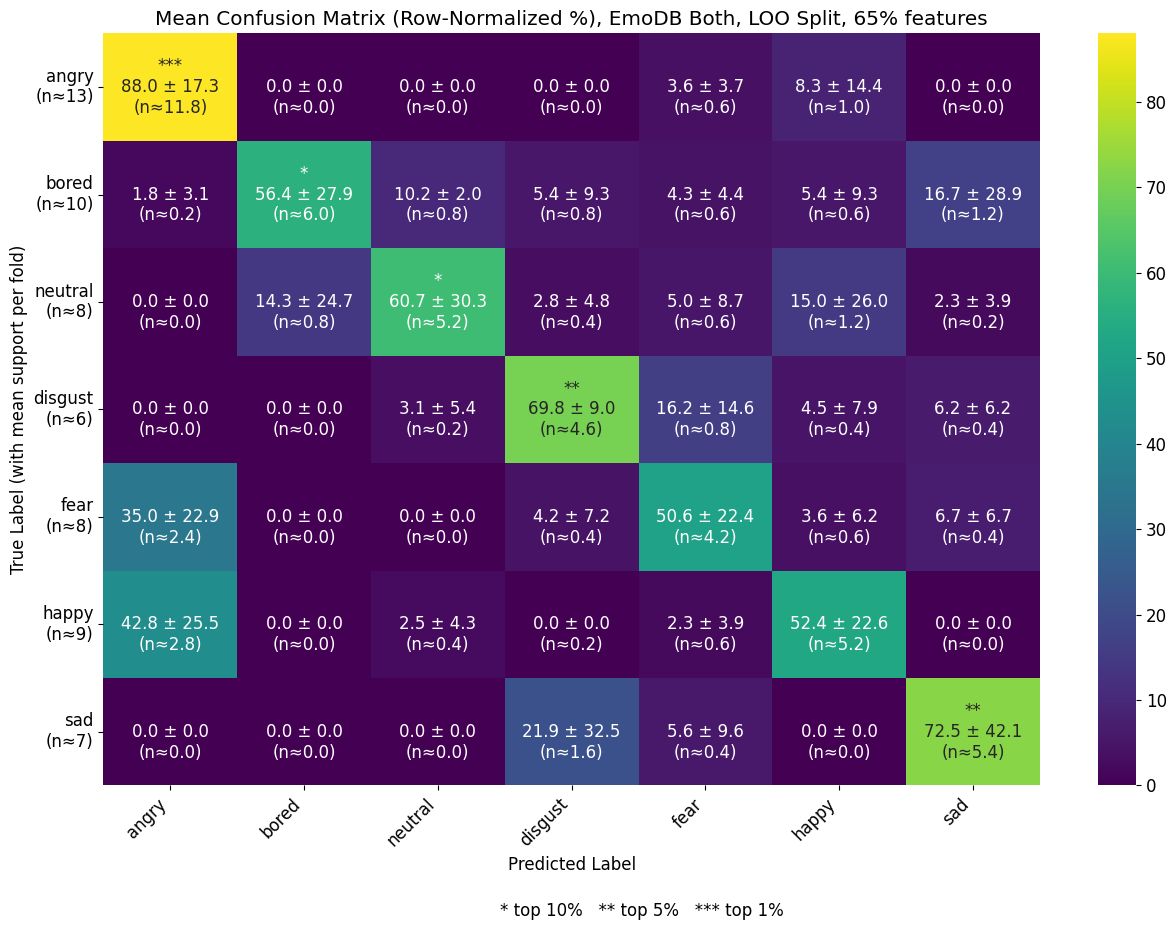

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 12})

conf_matrices_percent = conf_matrices / conf_matrices.sum(axis=2, keepdims=True) * 100

valid_folds = conf_matrices.sum(axis=2)[:, 3] > 0  # index 3 = disgust
conf_matrices_percent = conf_matrices_percent[valid_folds]

np.save('cm_emodb_speaker_both.npy', conf_matrices_percent)

mean_cm = np.mean(conf_matrices_percent, axis=0)
std_cm = np.std(conf_matrices_percent, axis=0)

# Mean raw counts per fold
mean_counts = np.mean(conf_matrices, axis=0)

# Compute percentile thresholds for annotation
flat_vals = mean_cm.flatten()
thr_90 = np.percentile(flat_vals, 90)
thr_95 = np.percentile(flat_vals, 95)
thr_99 = np.percentile(flat_vals, 99)

# Create annotation labels with significance symbols + raw counts
labels = np.empty(mean_cm.shape, dtype=object)
for i in range(mean_cm.shape[0]):
    for j in range(mean_cm.shape[1]):
        val = mean_cm[i, j]
        symbol = ""
        if val >= thr_99:
            symbol = "***"
        elif val >= thr_95:
            symbol = "**"
        elif val >= thr_90:
            symbol = "*"
        labels[i, j] = f"{symbol}\n{val:.1f} ± {std_cm[i, j]:.1f}\n(n≈{mean_counts[i, j]:.1f})"

listik = ['angry', 'bored', 'neutral', 'disgust', 'fear', 'happy', 'sad']

# Per-class support (mean samples per true class per fold)
mean_support = np.mean(conf_matrices.sum(axis=2), axis=0)
row_labels = [f"{name}\n(n≈{sup:.0f})" for name, sup in zip(listik, mean_support)]

# Plot
plt.figure(figsize=(13, 9))
ax = sns.heatmap(mean_cm, annot=labels, fmt="", cmap="viridis", cbar=True)
ax.set_xticks(np.arange(len(listik)) + 0.5)
ax.set_yticks(np.arange(len(listik)) + 0.5)
ax.set_xticklabels(listik, rotation=45, ha="right")
ax.set_yticklabels(row_labels, rotation=0)
plt.title("Mean Confusion Matrix (Row-Normalized %), EmoDB Both, LOO Split, 65% features")
plt.xlabel("Predicted Label")
plt.ylabel("True Label (with mean support per fold)")
plt.tight_layout()
plt.figtext(0.5, -0.05,
            "* top 10%   ** top 5%   *** top 1%\n",
            ha="center", fontsize=12)
plt.savefig("cm_emodb_speaker_both.eps", bbox_inches='tight')
plt.show()